# 第三节课实验：1D 热传导方程的 PINN（可运行版）

本 Notebook 目标：
1. 跑通一个最小 PINN；
2. 可视化预测解、真解、误差；
3. 通过改超参数做课堂互动实验。

## 1. 导入库与基础设置

In [21]:
import time
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


## 2. 问题定义

我们求解：
$$
\frac{\partial u}{\partial t} = \alpha\frac{\partial^2 u}{\partial x^2},\quad x\in[0,1], t\in[0,1]
$$

条件：
$$
u(x,0)=\sin(\pi x),\quad u(0,t)=u(1,t)=0
$$

解析解（用于评估）：
$$
u(x,t)=e^{-\alpha\pi^2 t}\sin(\pi x)
$$

In [34]:
alpha = 0.1

# 训练超参数（课堂上可改）
N_ic = 100
N_bc = 100
N_f = 2000

hidden_dim = 64
num_hidden = 4
lr = 1e-3
epochs = 9000

lambda_ic = 1.0
lambda_bc = 1.0
lambda_f = 5.0
# Dropout?PINN???????????
dropout_rate = 0.1


## 3. 构造训练点（IC / BC / Collocation）

In [36]:
# IC: (x, 0)
x_ic = np.random.rand(N_ic, 1)
t_ic = np.zeros((N_ic, 1))
u_ic = np.sin(np.pi * x_ic)

# BC: (0, t) 和 (1, t)
t_bc = np.random.rand(N_bc, 1)
x_bc0 = np.zeros((N_bc, 1))
x_bc1 = np.ones((N_bc, 1))
u_bc0 = np.zeros((N_bc, 1))
u_bc1 = np.zeros((N_bc, 1))

# 内部 collocation 点
x_f = np.random.rand(N_f, 1)
t_f = np.random.rand(N_f, 1)

# 转成 torch
def to_tensor(a, requires_grad=False):
    return torch.tensor(a, dtype=torch.float32, device=device, requires_grad=requires_grad)

x_ic_t = to_tensor(x_ic)
t_ic_t = to_tensor(t_ic)
u_ic_t = to_tensor(u_ic)

x_bc0_t = to_tensor(x_bc0)
x_bc1_t = to_tensor(x_bc1)
t_bc_t = to_tensor(t_bc)
u_bc0_t = to_tensor(u_bc0)
u_bc1_t = to_tensor(u_bc1)

x_f_t = to_tensor(x_f, requires_grad=True)
t_f_t = to_tensor(t_f, requires_grad=True)

print('IC points:', x_ic_t.shape[0])
print('BC points:', x_bc0_t.shape[0] * 2)
print('F points :', x_f_t.shape[0])

IC points: 100
BC points: 200
F points : 2000


## 4. 定义 PINN 网络

In [37]:
class PINN(nn.Module):
    def __init__(self, in_dim=2, out_dim=1, hidden_dim=64, num_hidden=3, dropout_rate=0.0):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_dim), nn.Tanh()]
        if dropout_rate > 0:
            layers.append(nn.Dropout(dropout_rate))

        for _ in range(num_hidden - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))

        layers += [nn.Linear(hidden_dim, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x, t):
        xt = torch.cat([x, t], dim=1)
        return self.net(xt)

model = PINN(hidden_dim=hidden_dim, num_hidden=num_hidden, dropout_rate=dropout_rate).to(device)
print(model)

PINN(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): Tanh()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): Tanh()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=64, out_features=64, bias=True)
    (7): Tanh()
    (8): Dropout(p=0.1, inplace=False)
    (9): Linear(in_features=64, out_features=64, bias=True)
    (10): Tanh()
    (11): Dropout(p=0.1, inplace=False)
    (12): Linear(in_features=64, out_features=1, bias=True)
  )
)


## 5. 自动微分与 PDE 残差

In [38]:
def gradients(y, x):
    return torch.autograd.grad(
        y, x,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True
    )[0]


def pde_residual(model, x, t, alpha):
    u = model(x, t)
    u_t = gradients(u, t)
    u_x = gradients(u, x)
    u_xx = gradients(u_x, x)
    f = u_t - alpha * u_xx
    return f

## 6. 训练（Adam）

In [39]:
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
loss_history = []

start = time.time()
for epoch in range(1, epochs + 1):
    optimizer.zero_grad()

    # IC loss
    u_ic_pred = model(x_ic_t, t_ic_t)
    loss_ic = torch.mean((u_ic_pred - u_ic_t) ** 2)

    # BC loss
    u_bc0_pred = model(x_bc0_t, t_bc_t)
    u_bc1_pred = model(x_bc1_t, t_bc_t)
    loss_bc = torch.mean((u_bc0_pred - u_bc0_t) ** 2) + torch.mean((u_bc1_pred - u_bc1_t) ** 2)

    # PDE loss
    f = pde_residual(model, x_f_t, t_f_t, alpha)
    loss_f = torch.mean(f ** 2)

    loss = lambda_ic * loss_ic + lambda_bc * loss_bc + lambda_f * loss_f
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 300 == 0 or epoch == 1:
        print(f'Epoch {epoch:4d} | Total {loss.item():.4e} | IC {loss_ic.item():.4e} | BC {loss_bc.item():.4e} | PDE {loss_f.item():.4e}')

elapsed = time.time() - start
print(f'Training done in {elapsed:.2f} s')

Epoch    1 | Total 8.0971e-01 | IC 7.4066e-01 | BC 6.2475e-02 | PDE 1.3153e-03
Epoch  300 | Total 9.9211e-02 | IC 3.5940e-02 | BC 2.8682e-02 | PDE 6.9179e-03
Epoch  600 | Total 6.2138e-02 | IC 2.0429e-02 | BC 1.6451e-02 | PDE 5.0516e-03
Epoch  900 | Total 5.1226e-02 | IC 1.9360e-02 | BC 1.3116e-02 | PDE 3.7499e-03
Epoch 1200 | Total 4.2306e-02 | IC 1.3559e-02 | BC 1.1184e-02 | PDE 3.5129e-03
Epoch 1500 | Total 3.9860e-02 | IC 1.2196e-02 | BC 1.0767e-02 | PDE 3.3794e-03
Epoch 1800 | Total 3.8680e-02 | IC 1.2367e-02 | BC 1.0929e-02 | PDE 3.0767e-03
Epoch 2100 | Total 3.9084e-02 | IC 1.2506e-02 | BC 1.1807e-02 | PDE 2.9542e-03
Epoch 2400 | Total 3.4420e-02 | IC 1.1180e-02 | BC 9.2797e-03 | PDE 2.7921e-03
Epoch 2700 | Total 3.6210e-02 | IC 1.5645e-02 | BC 8.1684e-03 | PDE 2.4792e-03
Epoch 3000 | Total 3.3218e-02 | IC 1.0683e-02 | BC 9.1903e-03 | PDE 2.6689e-03
Epoch 3300 | Total 2.9713e-02 | IC 9.9151e-03 | BC 6.8084e-03 | PDE 2.5979e-03
Epoch 3600 | Total 2.9855e-02 | IC 9.0551e-03 | BC 8

## 7. 训练曲线

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


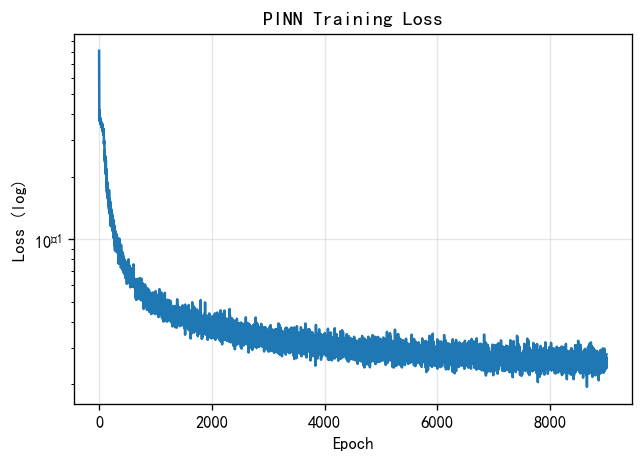

In [40]:
plt.figure(figsize=(6,4))
plt.semilogy(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss (log)')
plt.title('PINN Training Loss')
plt.grid(alpha=0.3)
plt.show()

## 8. 网格评估与误差指标

In [41]:
# 评估网格
nx, nt = 200, 200
x_eval = np.linspace(0, 1, nx)
t_eval = np.linspace(0, 1, nt)
X, T = np.meshgrid(x_eval, t_eval)

XT = np.hstack([X.reshape(-1, 1), T.reshape(-1, 1)])
xt_tensor = torch.tensor(XT, dtype=torch.float32, device=device)

with torch.no_grad():
    u_pred = model(xt_tensor[:, :1], xt_tensor[:, 1:2]).cpu().numpy().reshape(nt, nx)

u_exact = np.exp(-alpha * np.pi**2 * T) * np.sin(np.pi * X)

abs_err = np.abs(u_pred - u_exact)
l2_rel = np.linalg.norm(u_pred - u_exact) / np.linalg.norm(u_exact)
print(f'L2 relative error: {l2_rel:.4e}')

L2 relative error: 1.4960e-01


## 9. 三张核心图：预测 / 真解 / 绝对误差

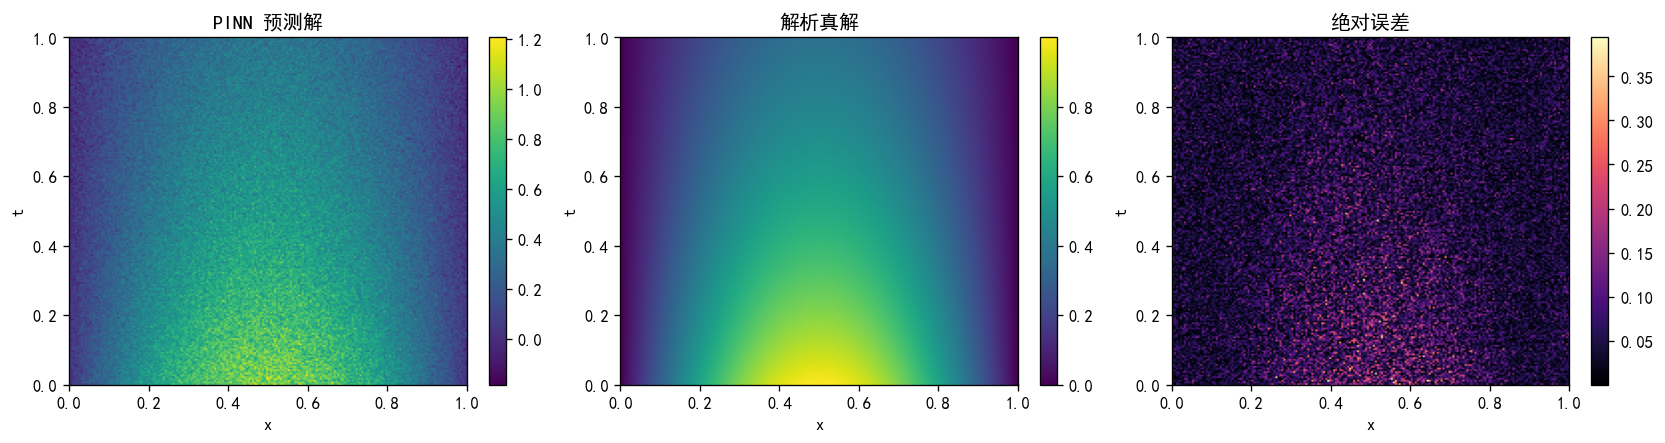

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

im0 = axes[0].imshow(u_pred, extent=[0,1,0,1], origin='lower', aspect='auto', cmap='viridis')
axes[0].set_title('PINN 预测解')
axes[0].set_xlabel('x')
axes[0].set_ylabel('t')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(u_exact, extent=[0,1,0,1], origin='lower', aspect='auto', cmap='viridis')
axes[1].set_title('解析真解')
axes[1].set_xlabel('x')
axes[1].set_ylabel('t')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(abs_err, extent=[0,1,0,1], origin='lower', aspect='auto', cmap='magma')
axes[2].set_title('绝对误差')
axes[2].set_xlabel('x')
axes[2].set_ylabel('t')
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

## 10. 时间切片对比图（课堂讲解很直观）

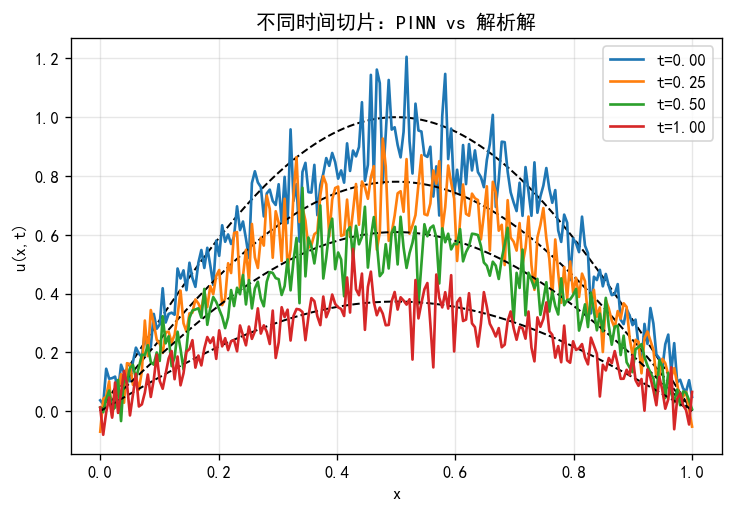

In [43]:
time_slices = [0.0, 0.25, 0.5, 1.0]

plt.figure(figsize=(7,4.5))
for ts in time_slices:
    idx = np.argmin(np.abs(t_eval - ts))
    plt.plot(x_eval, u_exact[idx], 'k--', linewidth=1.2)
    plt.plot(x_eval, u_pred[idx], linewidth=1.6, label=f't={t_eval[idx]:.2f}')

plt.xlabel('x')
plt.ylabel('u(x,t)')
plt.title('不同时间切片：PINN vs 解析解')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 11. 课堂可改参数建议

1. `N_f`：内部点数量，观察误差变化；
2. `lambda_f`：PDE 损失权重，观察三项 loss 平衡；
3. `num_hidden` / `hidden_dim`：模型容量与训练时间折中；
4. `epochs`：先用小迭代快速调通，再加大。
5. `dropout_rate`????? `0.01~0.05`??????? PDE ?????
